In [25]:
import torch
import torch.nn as nn
from torch.distributions import MultivariateNormal
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import optparse
import pickle

import matplotlib.pyplot as plt

import sac.memory as mem
from sac.feedforward import Feedforward
# import SAC
from sac.DDPG import DDPGAgent
from sac.utils import *

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(1)

In [26]:
env_name = "Pendulum-v1"
env = gym.make(env_name)

In [27]:
render = False
log_interval = 20           # print avg reward in the interval
new_episodes = 40 # max training episodes
max_timesteps = 2000   
save_interval = 500

In [28]:
params = SB3_PARAMS
params["alpha"] = 0.1
# params["entropy"] = -1
params["lr"] = 1e-3
# params["lr_critic"] = 1e-3
params["tau"] = 0.995

In [29]:
random_seed = 0

In [30]:
if random_seed is not None:
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)

In [31]:
hidden_sizes = [128, 128]
action_bounds = (env.action_space.low, env.action_space.high)
obs_dim = env.observation_space.shape[0]
sac = from_dict(hidden_sizes=hidden_sizes, obs_dim=obs_dim, action_bounds=action_bounds, **params)
# sac = hl_sac(hidden_sizes=hidden_sizes, obs_dim=obs_dim, action_bounds=action_bounds, **params)

In [32]:
agent = sac
agent_name = "HLSAC"

In [33]:
filepath = f"./results/hlgauss/{agent_name}-{env_name}-{random_seed}"

In [34]:
warmup_agent(agent, env, 256, max_timesteps)

In [35]:
losses = []
rewards = []
lengths = []
i_episode = 0

In [36]:
losses, rewards, lengths, i_episode, alphas = train_agent(agent, env, i_episode, new_episodes, max_timesteps, filepath, losses, rewards, lengths, log_interval=1, save_interval=20, train_interval=1)

Episode 1 	 avg length: 200 	 reward: -1317.7475191629624
Episode 2 	 avg length: 200 	 reward: -1531.598608932415
Episode 3 	 avg length: 200 	 reward: -1336.999301407256
Episode 4 	 avg length: 200 	 reward: -1528.7467770565054
Episode 5 	 avg length: 200 	 reward: -1556.086372547092
Episode 6 	 avg length: 200 	 reward: -1381.6673192370356
Episode 7 	 avg length: 200 	 reward: -1239.2815134648556
Episode 8 	 avg length: 200 	 reward: -1074.3866126825822
Episode 9 	 avg length: 200 	 reward: -1016.7129704542772
Episode 10 	 avg length: 200 	 reward: -781.6514769995024
Episode 11 	 avg length: 200 	 reward: -519.7450800477758
Episode 12 	 avg length: 200 	 reward: -261.2687654552824
Episode 13 	 avg length: 200 	 reward: -253.80871283860074
Episode 14 	 avg length: 200 	 reward: -243.97261929886486
Episode 15 	 avg length: 200 	 reward: -1.2456464328175256
Episode 16 	 avg length: 200 	 reward: -126.35546620332795
Episode 17 	 avg length: 200 	 reward: -119.81622498970083
Episode 18 	

KeyboardInterrupt: 

In [ ]:
rewards, lengths, losses = load_stats(filepath) 

In [13]:
from sac.plots import *

In [14]:
plot_path = "plots3"

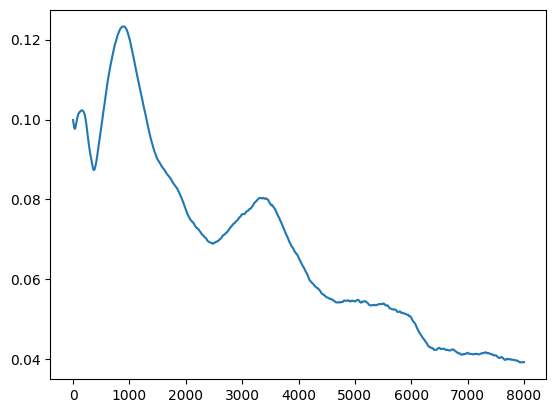

In [85]:
plt.plot(alphas)
plt.savefig(f"plots3/alphas.png")

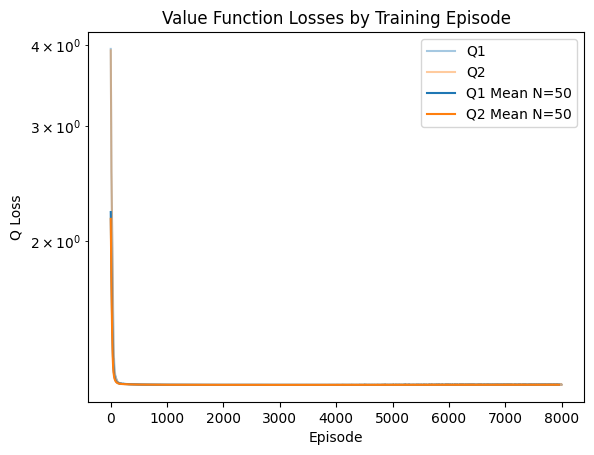

In [86]:
q_losses = np.asarray(losses)[:,:2]
plot_q(q_losses, plot_path)

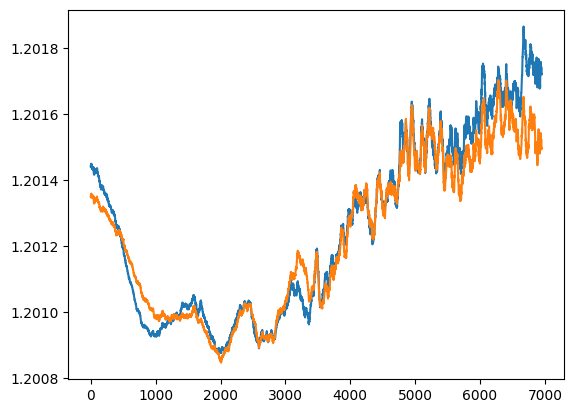

In [87]:
plt.plot(running_mean(q_losses[1000:, 0], 50))
plt.plot(running_mean(q_losses[1000:, 1], 50))
plt.savefig("plots3/Q_close.png")

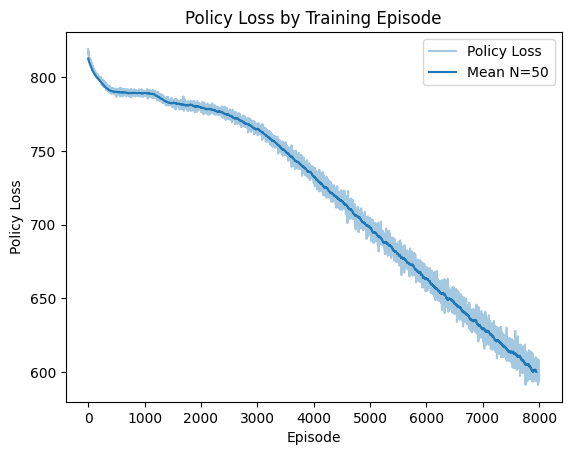

In [88]:
policy_loss = np.asarray(losses)[:,2]
plot_policy_loss(policy_loss, plot_path)

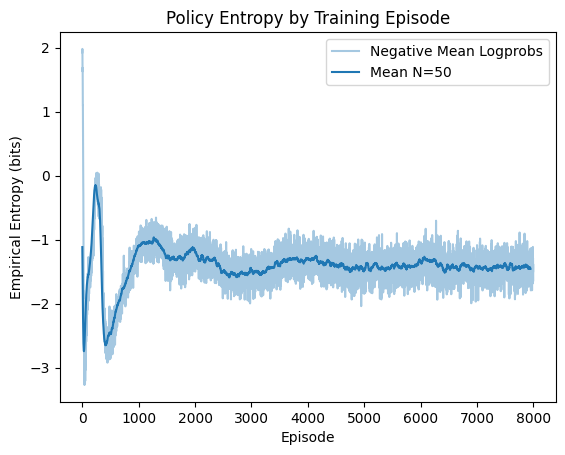

In [89]:
logprobs = np.asarray(losses)[:,-1]
plot_entropy(logprobs, plot_path)

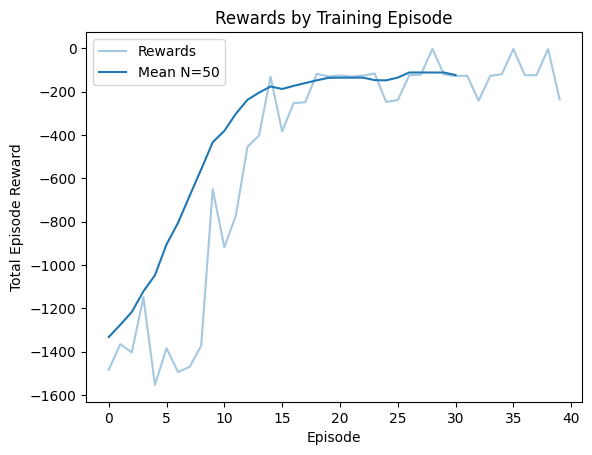

In [60]:
plot_rewards(rewards, plot_path, 10)

In [33]:
with torch.no_grad():
    s, a, _, _, _ = agent.get_batch()
    print(agent.Q1.loss(agent.Q1.Q_value(s, a)))
    print(agent.Q1.Q_value(s, a)[0])
    test_targets = torch.full((256,), -100)
    print(agent.Q1.loss(agent.Q1.Q_value(s, a), test_targets))

tensor([ -71.6393, -179.5056,  -71.7374, -277.6979,  -71.7534,  -71.7034,
         -71.6547,  -71.6294,  -71.6591,  -73.3048,  -71.6696,  -71.6219,
        -211.7365,  -71.6733,  -71.6416,  -73.7289,  -71.5934,  -71.6731,
         -71.6570,  -71.7281,  -71.6281,  -71.6121,  -71.6365,  -71.6622,
         -71.6239,  -71.7181,  -71.6232,  -71.6882, -101.0208, -179.5164,
         -71.6409,  -71.7225, -256.6016,  -71.7846, -293.6045, -283.5253,
         -71.5543,  -71.6925,  -71.6213, -295.1496,  -71.7224,  -71.6445,
         -71.6171,  -71.6469,  -71.7227, -180.2595,  -71.6788,  -71.6482,
        -172.6176,  -71.6554, -173.3207,  -71.6636,  -71.6518,  -74.2412,
        -244.2390,  -71.6726,  -71.7583,  -71.6950,  -71.6522,  -71.6125,
         -71.6331,  -71.6493,  -71.8222, -101.9219,  -71.6986,  -73.6120,
         -71.6329,  -71.7455,  -71.6297,  -71.6491, -183.9254,  -71.7514,
         -71.6359,  -72.4383,  -71.6412,  -71.6112,  -71.6611,  -87.9759,
         -73.2794,  -71.6488,  -71.649